In [1]:
# TP1 – Pandas (Iris Dataset)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [2]:
# 1) Load the Iris dataset and display the first 5 rows
iris = load_iris(as_frame=True)
df = iris.frame.copy()
print("First 5 rows:")
display(df.head())

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# 3) Show statistical summary with describe()
print("\n3) Statistical summary (describe):")
display(df.describe())


3) Statistical summary (describe):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# 4) Rename columns to more explicit names
df = df.rename(columns={
    "sepal length (cm)": "SepalLengthCm",
    "sepal width (cm)":  "SepalWidthCm",
    "petal length (cm)": "PetalLengthCm",
    "petal width (cm)":  "PetalWidthCm",
    "target":            "SpeciesId"
})
print("\n4) Columns renamed:")
print(df.columns)

# (Recommended) Add a readable species label (names instead of numeric IDs)
species_map = dict(enumerate(iris.target_names))
df["Species"] = df["SpeciesId"].map(species_map)
print("\nAdded 'Species' column (readable labels):")
display(df.head())


4) Columns renamed:
Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'SpeciesId'],
      dtype='str')

Added 'Species' column (readable labels):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,SpeciesId,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [6]:
# 5) Add a new column: petal length/width ratio
df["PetalRatio"] = df["PetalLengthCm"] / df["PetalWidthCm"]
print("\n5) Added 'PetalRatio' column:")
display(df.head())


5) Added 'PetalRatio' column:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,SpeciesId,Species,PetalRatio
0,5.1,3.5,1.4,0.2,0,setosa,7.0
1,4.9,3.0,1.4,0.2,0,setosa,7.0
2,4.7,3.2,1.3,0.2,0,setosa,6.5
3,4.6,3.1,1.5,0.2,0,setosa,7.5
4,5.0,3.6,1.4,0.2,0,setosa,7.0


In [7]:
# 6) Drop an unnecessary column (example: SpeciesId)
df = df.drop(columns=["SpeciesId"])
print("\n6) Dropped 'SpeciesId' column:")
print(df.columns)


6) Dropped 'SpeciesId' column:
Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species', 'PetalRatio'],
      dtype='str')


In [8]:
# 7) Remove rows where sepal length is less than 5.0
df = df[df["SepalLengthCm"] >= 5.0].reset_index(drop=True)
print("\n7) After filtering SepalLengthCm >= 5.0, new shape:")
print(df.shape)


7) After filtering SepalLengthCm >= 5.0, new shape:
(128, 6)


In [9]:
# 8) Filter rows for the species "setosa"
setosa_df = df[df["Species"] == "setosa"]
print("\n8) Setosa-only dataframe (first 5 rows):")
display(setosa_df.head())


8) Setosa-only dataframe (first 5 rows):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,PetalRatio
0,5.1,3.5,1.4,0.2,setosa,7.00
1,5.0,3.6,1.4,0.2,setosa,7.00
2,5.4,3.9,1.7,0.4,setosa,4.25
3,5.0,3.4,1.5,0.2,setosa,7.50
4,5.4,3.7,1.5,0.2,setosa,7.50


In [10]:
# 9) Count the number of samples per species
print("\n9) Counts per species:")
display(df["Species"].value_counts())



9) Counts per species:


Species
versicolor    49
virginica     49
setosa        30
Name: count, dtype: int64

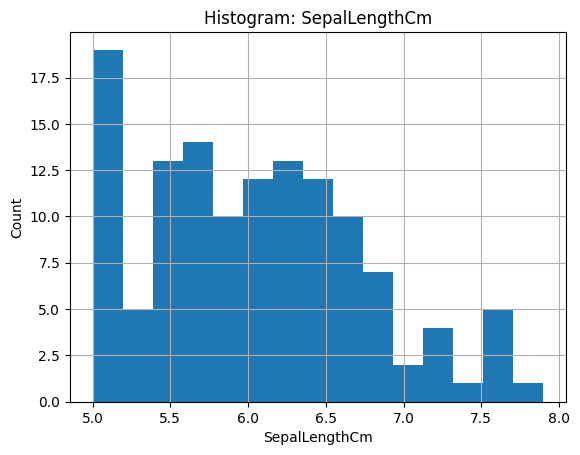

In [11]:
# 10) Visualizations: histogram, scatter plot, boxplot

# 10.1 Histogram of a variable
plt.figure()
df["SepalLengthCm"].hist(bins=15)
plt.title("Histogram: SepalLengthCm")
plt.xlabel("SepalLengthCm")
plt.ylabel("Count")
plt.show()


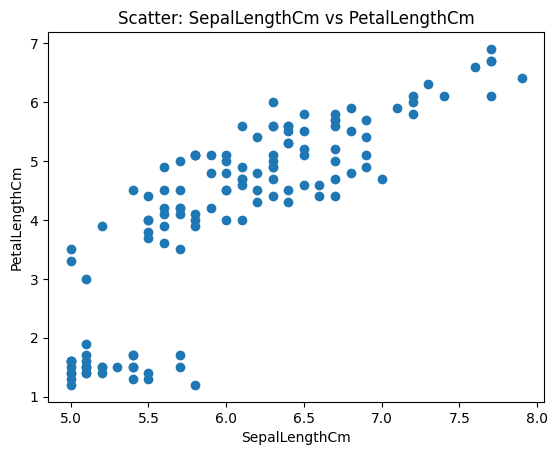

In [12]:
# 10.2 Scatter plot between two variables
plt.figure()
plt.scatter(df["SepalLengthCm"], df["PetalLengthCm"])
plt.title("Scatter: SepalLengthCm vs PetalLengthCm")
plt.xlabel("SepalLengthCm")
plt.ylabel("PetalLengthCm")
plt.show()

<Figure size 640x480 with 0 Axes>

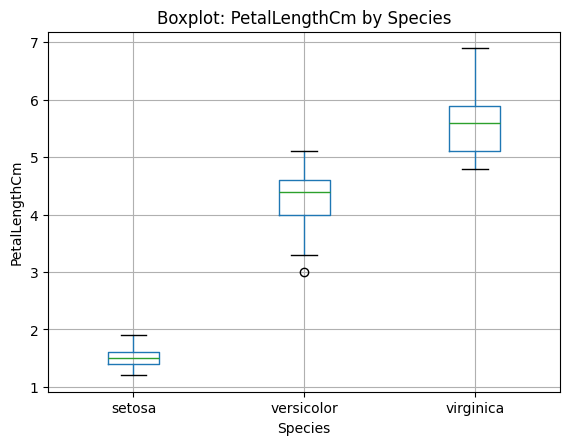

In [28]:
# 10.3 Boxplot comparing species
plt.figure()
df.boxplot(column="PetalLengthCm", by="Species")
plt.title("Boxplot: PetalLengthCm by Species")
plt.suptitle("")  # remove the automatic "Boxplot grouped by ..." title
plt.xlabel("Species")
plt.ylabel("PetalLengthCm")
plt.show()